# Bank Marketing Dataset - EDA Analysis
**Project Goal:** Predict customer subscription to a term deposit using demographic, financial, and campaign features.
**Target:** `y` (yes/no).

This notebook is designed for academic submission and professional reporting.

## 1. Introduction
**Business Problem:** A bank wants to maximize term deposit subscriptions while minimizing campaign cost.
**Objectives:** Identify key drivers, understand campaign effectiveness, and build a strong analytical foundation.
**Business Value:** Better targeting improves conversion, reduces cost, and supports sustainable growth.

In [1]:
# Core libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

# Shared color palette for charts
COLOR_PALETTE = ["#1F6FEB", "#2EC4B6", "#F4A259", "#9B5DE5", "#E63946", "#0B2545"]
OUTCOME_PALETTE = {"no": "#0B2545", "yes": "#2EC4B6"}
sns.set_palette(COLOR_PALETTE)


# Resolve project root
project_root = Path.cwd()
if not (project_root / "bank" / "bank-full.csv").exists():
    project_root = project_root.parent

# Load dataset
data_path = project_root / "bank" / "bank-full.csv"
df = pd.read_csv(data_path, sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2. Data Understanding
We inspect the dataset structure, data types, missing values, unknown values, and duplicates.

In [2]:
# Shape and data types
print('Rows, Columns:', df.shape)
display(df.info())

# Missing values (NaN)
missing_counts = df.isna().sum().sort_values(ascending=False)
display(missing_counts.head(10))

# 'unknown' value counts
unknown_counts = (df == 'unknown').sum().sort_values(ascending=False)
display(unknown_counts[unknown_counts > 0])

# Duplicate records
duplicate_count = df.duplicated().sum()
print('Duplicate rows:', duplicate_count)

# Statistical summary
display(df.describe(include='all').T)

Rows, Columns: (45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


None

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
dtype: int64

poutcome     36959
contact      13020
education     1857
job            288
dtype: int64

Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


In [3]:
# Data dictionary
data_dict = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.values,
    'description': [
        'Customer age',
        'Type of job',
        'Marital status',
        'Education level',
        'Has credit in default',
        'Average yearly account balance',
        'Has housing loan',
        'Has personal loan',
        'Communication type',
        'Last contact day',
        'Last contact month',
        'Last contact duration in seconds',
        'Number of contacts during current campaign',
        'Days since previous contact',
        'Number of previous contacts',
        'Previous campaign outcome',
        'Subscription result (target)'
    ]
})
data_dict

,column,dtype,description
0,age,int64,Customer age
1,job,object,Type of job
2,marital,object,Marital status
3,education,object,Education level
4,default,object,Has credit in default
5,balance,int64,Average yearly account balance
6,housing,object,Has housing loan
7,loan,object,Has personal loan
8,contact,object,Communication type
9,day,int64,Last contact day


## 3. Data Cleaning
We treat 'unknown' as missing, remove duplicates, and correct data types.
Outliers in numeric features are capped using IQR-based limits.

In [4]:
# Replace 'unknown' with NaN for proper missing value handling
df_clean = df.replace("unknown", np.nan)

# Missing value analysis after replacement
missing_after = df_clean.isna().sum().sort_values(ascending=False)
display(missing_after[missing_after > 0])

# Remove duplicates
before_rows = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after_rows = df_clean.shape[0]
print(f"Removed duplicates: {before_rows - after_rows}")

# Convert month to ordered category
month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]
df_clean["month"] = pd.Categorical(df_clean["month"], categories=month_order, ordered=True)

# Outlier capping for numeric columns
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

def cap_outliers(data, col):
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    data[col] = data[col].clip(lower, upper)

for col in numeric_cols:
    cap_outliers(df_clean, col)

df_clean[numeric_cols].describe().T

poutcome     36959
contact      13020
education     1857
job            288
dtype: int64

Removed duplicates: 0


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.868185,10.394895,18.0,33.0,39.0,48.0,70.5
balance,45211.0,933.706974,1176.765369,-1962.0,72.0,448.0,1428.0,3462.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,234.939307,176.749932,0.0,103.0,180.0,319.0,643.0
campaign,45211.0,2.392228,1.600111,1.0,1.0,2.0,3.0,6.0
pdays,45211.0,-1.000000,0.000000,-1.0,-1.0,-1.0,-1.0,-1.0
previous,45211.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


## Detailed Statistical Summary
We compute detailed statistics for numerical and categorical features and provide business interpretations.

In [5]:
# Numerical feature summary
numeric_features = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

def build_numeric_summary(data, cols):
    summary = pd.DataFrame(index=cols)
    summary["count"] = data[cols].count()
    summary["mean"] = data[cols].mean()
    summary["median"] = data[cols].median()
    summary["mode"] = data[cols].mode().iloc[0]
    summary["min"] = data[cols].min()
    summary["max"] = data[cols].max()
    summary["range"] = summary["max"] - summary["min"]
    summary["std"] = data[cols].std()
    summary["variance"] = data[cols].var()
    summary["skewness"] = data[cols].skew()
    summary["kurtosis"] = data[cols].kurt()
    summary["q1"] = data[cols].quantile(0.25)
    summary["q2"] = data[cols].quantile(0.50)
    summary["q3"] = data[cols].quantile(0.75)
    summary["iqr"] = summary["q3"] - summary["q1"]
    summary["p05"] = data[cols].quantile(0.05)
    summary["p25"] = data[cols].quantile(0.25)
    summary["p50"] = data[cols].quantile(0.50)
    summary["p75"] = data[cols].quantile(0.75)
    summary["p95"] = data[cols].quantile(0.95)
    return summary

numeric_summary = build_numeric_summary(df_clean, numeric_features)
display(numeric_summary)

# Skew-based interpretation per feature
for col in numeric_features:
    skew = numeric_summary.loc[col, "skewness"]
    if skew > 0.5:
        skew_label = "right-skewed"
    elif skew < -0.5:
        skew_label = "left-skewed"
    else:
        skew_label = "approximately symmetric"

    display(Markdown(
        f"**{col}**: mean={numeric_summary.loc[col, 'mean']:.2f}, "
        f"median={numeric_summary.loc[col, 'median']:.2f}, "
        f"{skew_label} (IQR={numeric_summary.loc[col, 'iqr']:.2f})."
    ))


,count,mean,median,mode,min,max,range,std,variance,skewness,kurtosis,q1,q2,q3,iqr,p05,p25,p50,p75,p95
age,45211,40.868185,39.0,32.0,18.0,70.5,52.5,10.394895,1.080538e+02,0.529715,-0.375981,33.0,39.0,48.0,15.0,27.0,33.0,39.0,48.0,59.0
balance,45211,933.706974,448.0,3462.0,-1962.0,3462.0,5424.0,1176.765369,1.384777e+06,1.097802,0.007675,72.0,448.0,1428.0,1356.0,-172.0,72.0,448.0,1428.0,3462.0
day,45211,15.806419,16.0,20.0,1.0,31.0,30.0,8.322476,6.926361e+01,0.093079,-1.059897,8.0,16.0,21.0,13.0,3.0,8.0,16.0,21.0,29.0
duration,45211,234.939307,180.0,643.0,0.0,643.0,643.0,176.749932,3.124054e+04,1.037574,0.107564,103.0,180.0,319.0,216.0,35.0,103.0,180.0,319.0,643.0
campaign,45211,2.392228,2.0,1.0,1.0,6.0,5.0,1.600111,2.560355e+00,1.099115,0.070302,1.0,2.0,3.0,2.0,1.0,1.0,2.0,3.0,6.0
pdays,45211,-1.000000,-1.0,-1.0,-1.0,-1.0,0.0,0.000000,0.000000e+00,0.000000,0.000000,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0
previous,45211,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**age**: mean=40.87, median=39.00, right-skewed (IQR=15.00).

**balance**: mean=933.71, median=448.00, right-skewed (IQR=1356.00).

**day**: mean=15.81, median=16.00, approximately symmetric (IQR=13.00).

**duration**: mean=234.94, median=180.00, right-skewed (IQR=216.00).

**campaign**: mean=2.39, median=2.00, right-skewed (IQR=2.00).

**pdays**: mean=-1.00, median=-1.00, approximately symmetric (IQR=0.00).

**previous**: mean=0.00, median=0.00, approximately symmetric (IQR=0.00).

### Categorical Feature: job

,count,percent,subscription_rate
job,,,
blue-collar,9732,21.53,7.27
management,9458,20.92,13.76
technician,7597,16.80,11.06
admin.,5171,11.44,12.20
services,4154,9.19,8.88
retired,2264,5.01,22.79
self-employed,1579,3.49,11.84
entrepreneur,1487,3.29,8.27
unemployed,1303,2.88,15.50


C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:25: UserWarning: 
The palette list has fewer values (6) than needed (12) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=summary_table.index, y=summary_table["percent"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


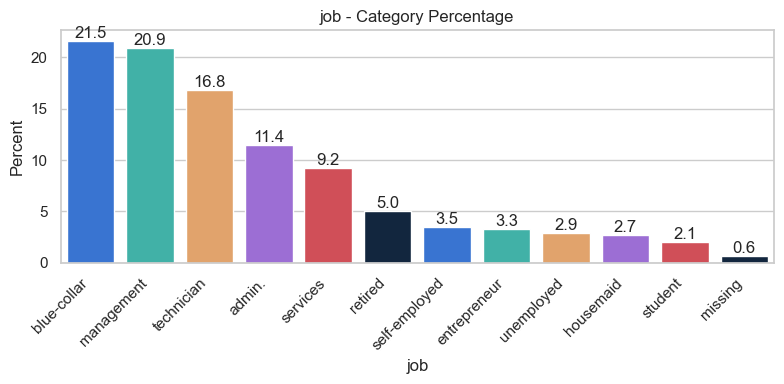

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:36: UserWarning: 
The palette list has fewer values (6) than needed (12) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=summary_table.index, y=summary_table["subscription_rate"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


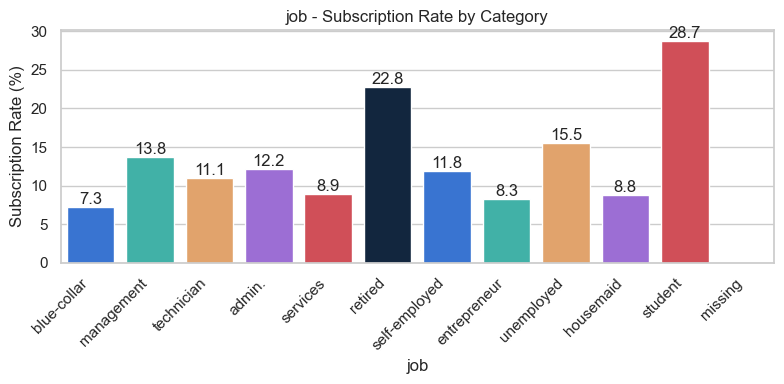

**job**: most common category is **blue-collar** (21.5% of customers); highest subscription rate is **student** (28.7%).

### Categorical Feature: marital

,count,percent,subscription_rate
marital,,,
married,27214,60.19,10.12
single,12790,28.29,14.95
divorced,5207,11.52,11.95


C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:25: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["percent"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


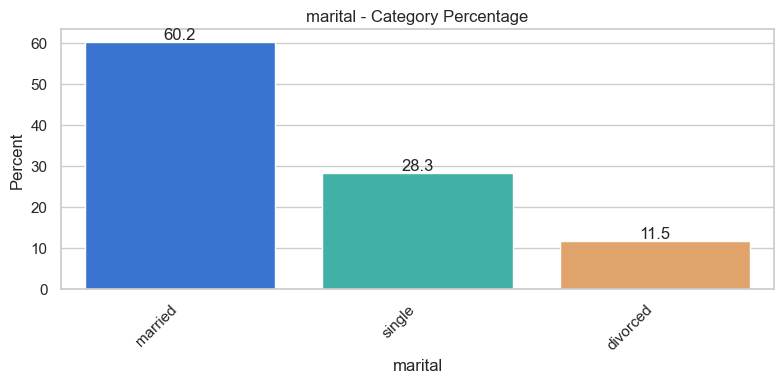

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:36: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["subscription_rate"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


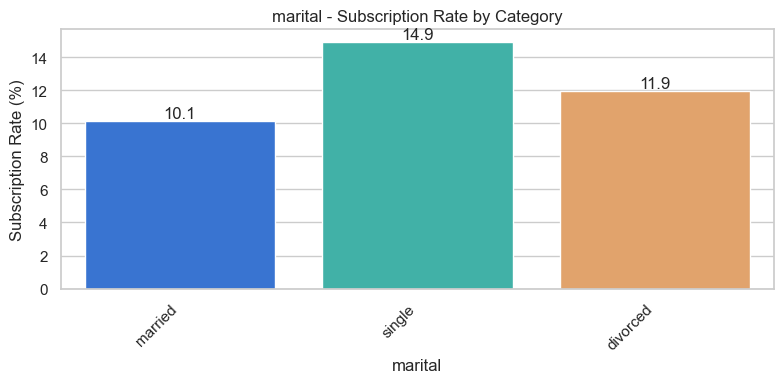

**marital**: most common category is **married** (60.2% of customers); highest subscription rate is **single** (14.9%).

### Categorical Feature: education

,count,percent,subscription_rate
education,,,
secondary,23202,51.32,10.56
tertiary,13301,29.42,15.01
primary,6851,15.15,8.63
missing,1857,4.11,NaN


C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:25: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["percent"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


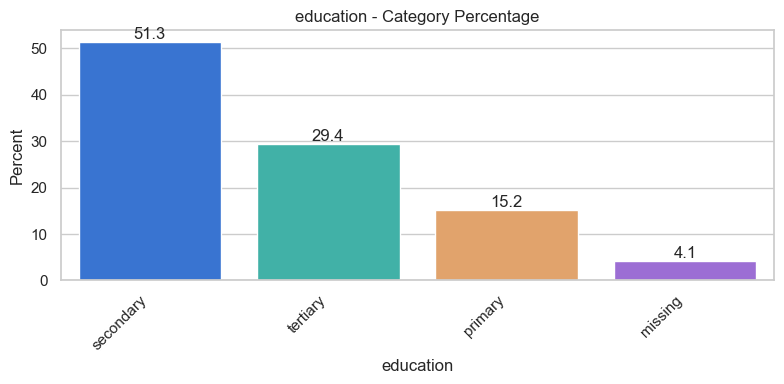

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:36: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["subscription_rate"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


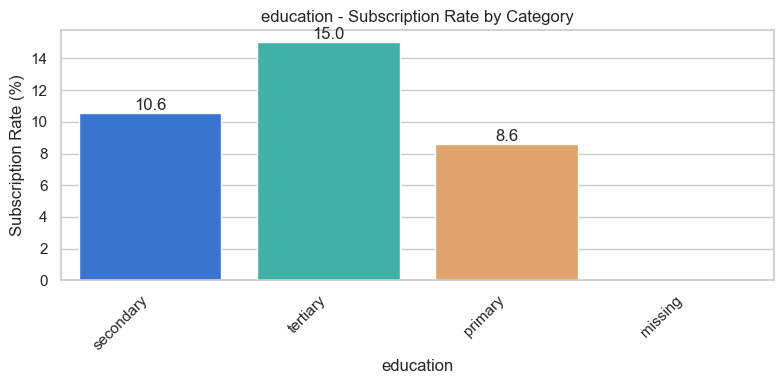

**education**: most common category is **secondary** (51.3% of customers); highest subscription rate is **tertiary** (15.0%).

### Categorical Feature: default

,count,percent,subscription_rate
default,,,
no,44396,98.2,11.80
yes,815,1.8,6.38


C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:25: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["percent"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


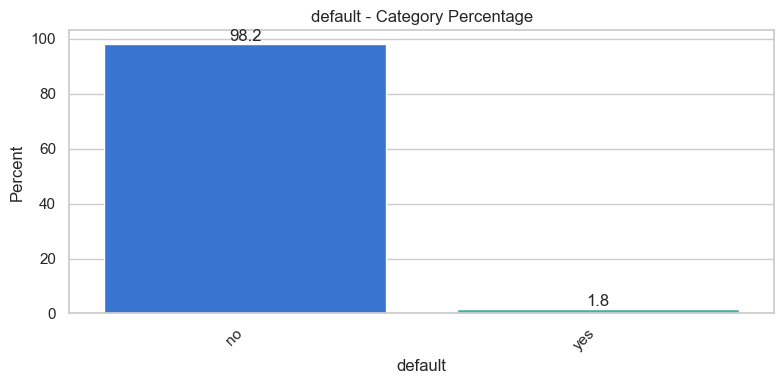

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:36: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["subscription_rate"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


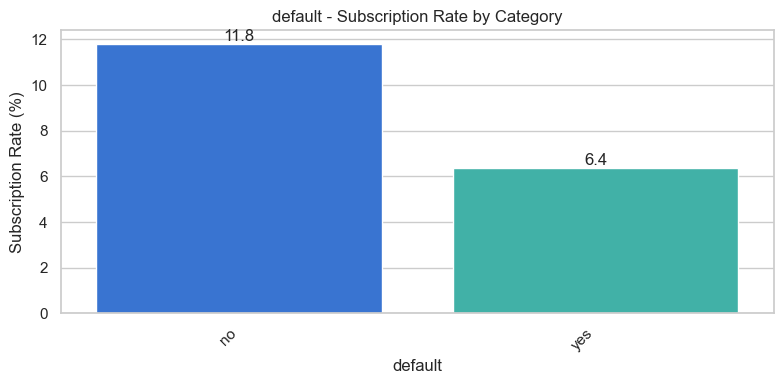

**default**: most common category is **no** (98.2% of customers); highest subscription rate is **no** (11.8%).

### Categorical Feature: housing

,count,percent,subscription_rate
housing,,,
yes,25130,55.58,7.7
no,20081,44.42,16.7


C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:25: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["percent"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


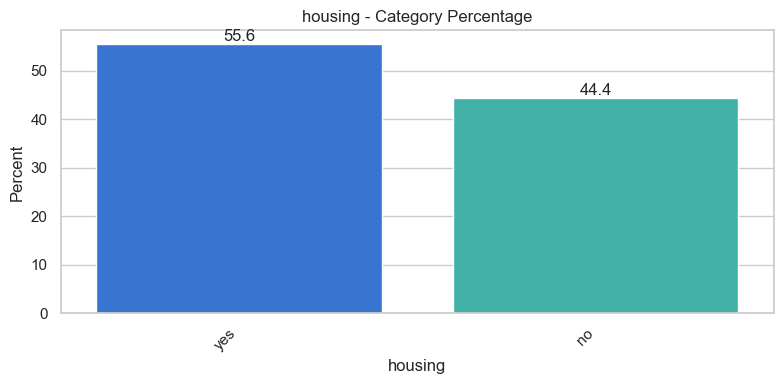

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:36: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["subscription_rate"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


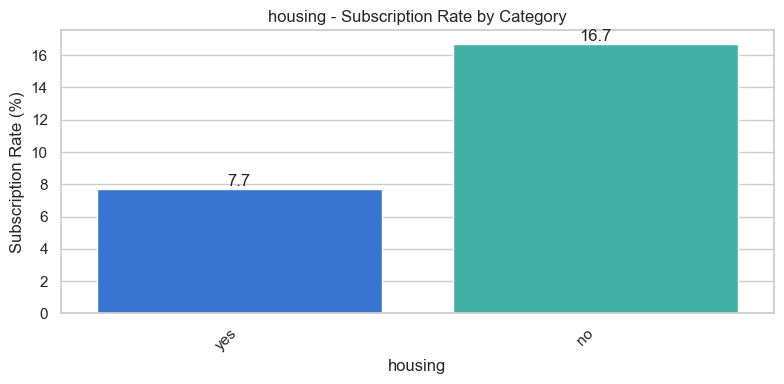

**housing**: most common category is **yes** (55.6% of customers); highest subscription rate is **no** (16.7%).

### Categorical Feature: loan

,count,percent,subscription_rate
loan,,,
no,37967,83.98,12.66
yes,7244,16.02,6.68


C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:25: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["percent"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


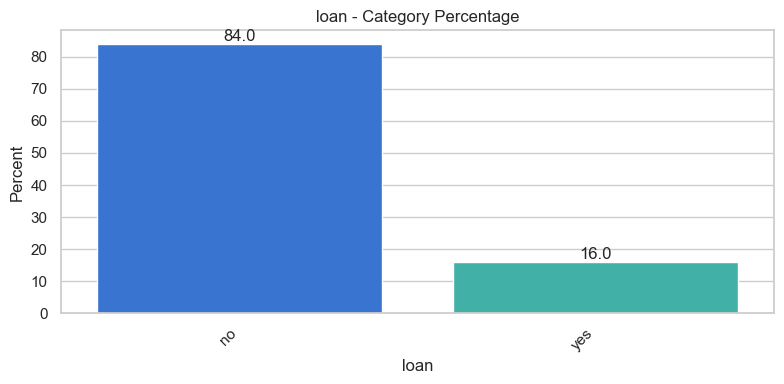

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:36: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["subscription_rate"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


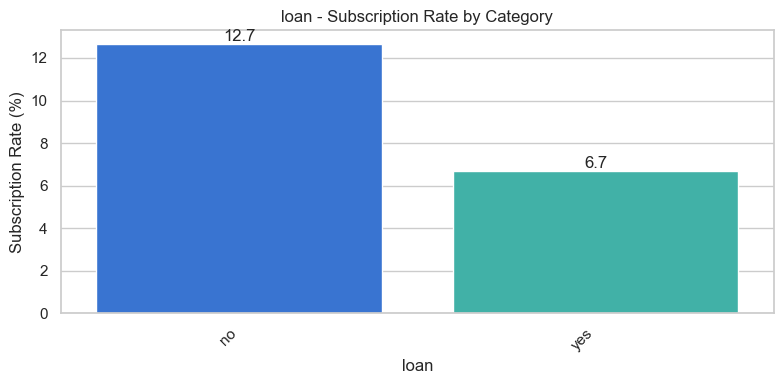

**loan**: most common category is **no** (84.0% of customers); highest subscription rate is **no** (12.7%).

### Categorical Feature: contact

,count,percent,subscription_rate
contact,,,
cellular,29285,64.77,14.92
missing,13020,28.80,NaN
telephone,2906,6.43,13.42


C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:25: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["percent"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


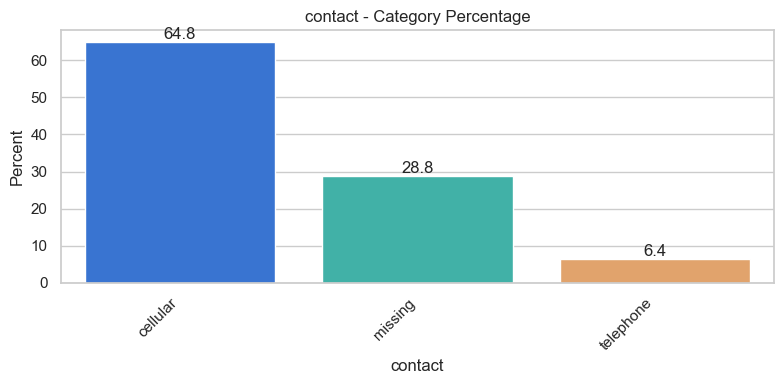

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:36: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["subscription_rate"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


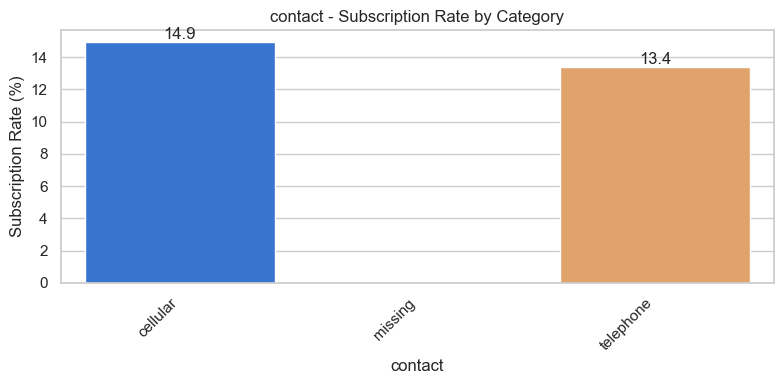

**contact**: most common category is **cellular** (64.8% of customers); highest subscription rate is **cellular** (14.9%).

### Categorical Feature: month

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(col)["y"].apply(lambda s: (s == "yes").mean())


,count,percent,subscription_rate
month,,,
may,13766,30.45,6.72
jul,6895,15.25,9.09
aug,6247,13.82,11.01
jun,5341,11.81,10.22
nov,3970,8.78,10.15
apr,2932,6.49,19.68
feb,2649,5.86,16.65
jan,1403,3.10,10.12
oct,738,1.63,43.77


C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:25: UserWarning: 
The palette list has fewer values (6) than needed (12) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=summary_table.index, y=summary_table["percent"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


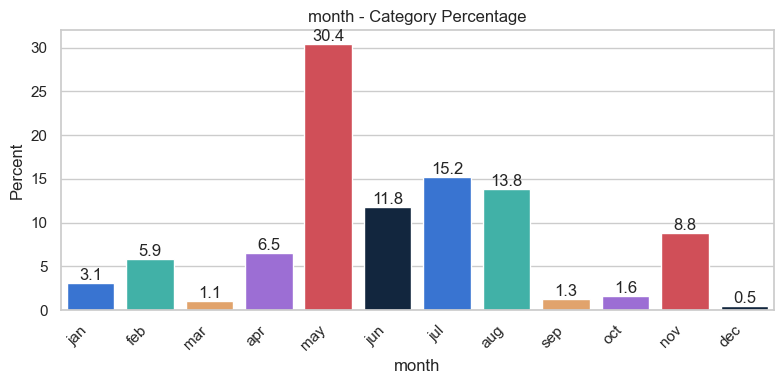

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:36: UserWarning: 
The palette list has fewer values (6) than needed (12) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=summary_table.index, y=summary_table["subscription_rate"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


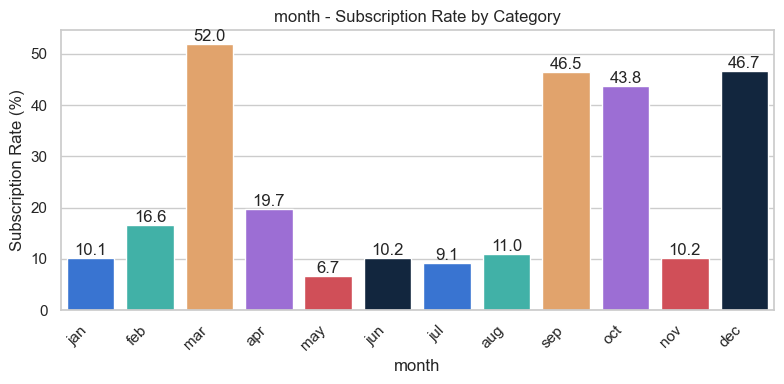

**month**: most common category is **may** (30.4% of customers); highest subscription rate is **mar** (52.0%).

### Categorical Feature: poutcome

,count,percent,subscription_rate
poutcome,,,
missing,36959,81.75,NaN
failure,4901,10.84,12.61
other,1840,4.07,16.68
success,1511,3.34,64.73


C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:25: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["percent"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


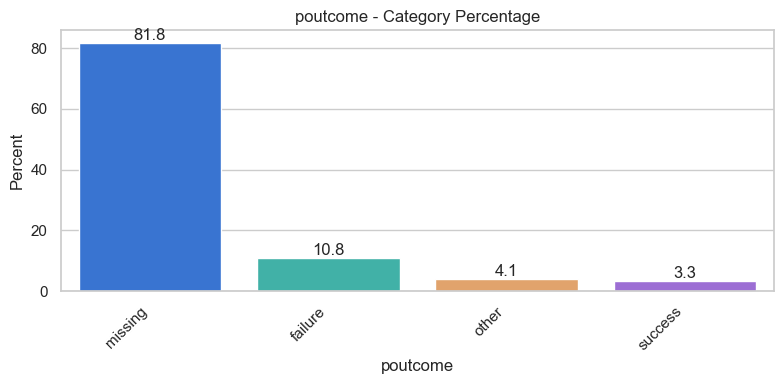

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:36: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["subscription_rate"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


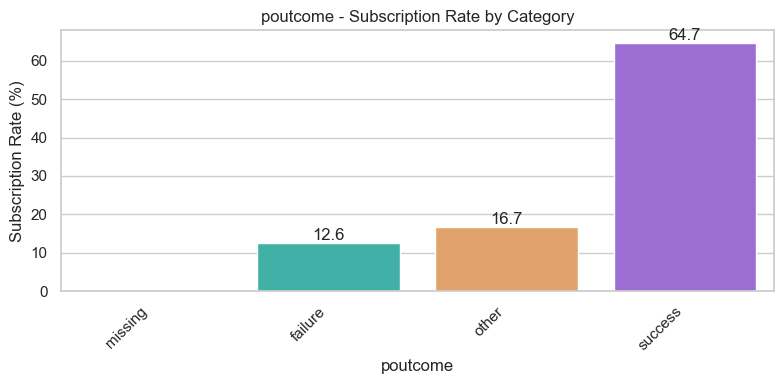

**poutcome**: most common category is **missing** (81.8% of customers); highest subscription rate is **success** (64.7%).

### Categorical Feature: y

,count,percent,subscription_rate
y,,,
no,39922,88.3,0.0
yes,5289,11.7,100.0


C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:25: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["percent"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


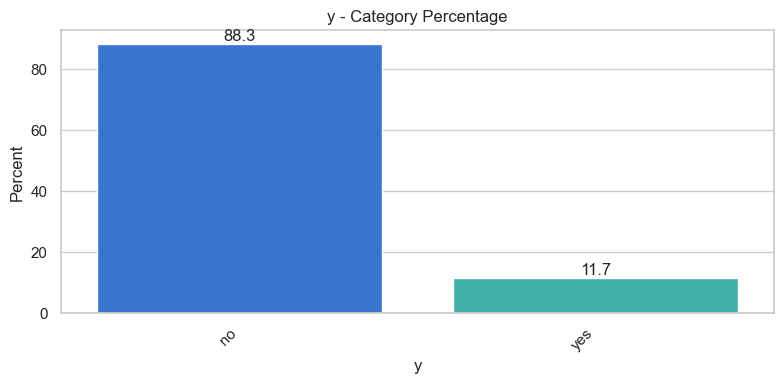

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3073961792.py:36: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.barplot(x=summary_table.index, y=summary_table["subscription_rate"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)


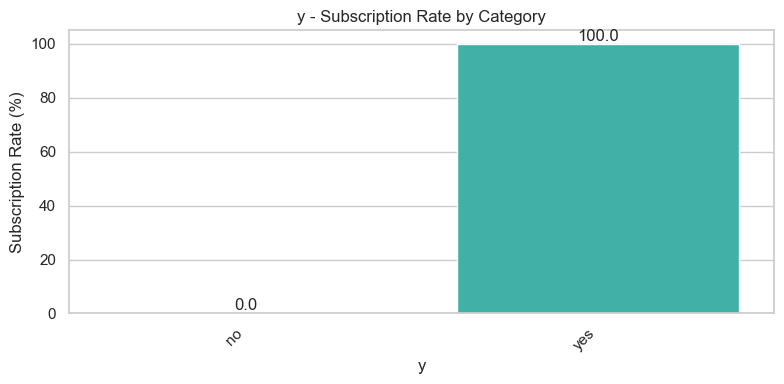

**y**: most common category is **no** (88.3% of customers); highest subscription rate is **yes** (100.0%).

In [6]:
# Categorical feature summary
categorical_features = [
    "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "poutcome", "y"
]

for col in categorical_features:
    display(Markdown(f"### Categorical Feature: {col}"))
    value_counts = df_clean[col].value_counts(dropna=False)
    percent = value_counts / value_counts.sum()
    subscription_rate = (
        df_clean.groupby(col)["y"].apply(lambda s: (s == "yes").mean())
        .reindex(value_counts.index)
    )
    summary_table = pd.DataFrame({
        "count": value_counts,
        "percent": (percent * 100).round(2),
        "subscription_rate": (subscription_rate * 100).round(2)
    })
    summary_table.index = summary_table.index.fillna("missing")
    display(summary_table)

    # Category share
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=summary_table.index, y=summary_table["percent"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f")
    plt.title(f"{col} - Category Percentage")
    plt.ylabel("Percent")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Subscription rate by category
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=summary_table.index, y=summary_table["subscription_rate"], hue=summary_table.index, palette=COLOR_PALETTE, legend=False)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f")
    plt.title(f"{col} - Subscription Rate by Category")
    plt.ylabel("Subscription Rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    top_category = summary_table["percent"].idxmax()
    best_sub = summary_table["subscription_rate"].idxmax()
    display(Markdown(
        f"**{col}**: most common category is **{top_category}** "
        f"({summary_table.loc[top_category, 'percent']:.1f}% of customers); highest subscription "
        f"rate is **{best_sub}** ({summary_table.loc[best_sub, 'subscription_rate']:.1f}%)."
    ))


## 4. Univariate Analysis
We examine distributions for numeric and categorical features and interpret their patterns.

**age**: skew=0.53 (right-skewed).

**balance**: skew=1.10 (right-skewed).

**day**: skew=0.09 (approximately symmetric).

**duration**: skew=1.04 (right-skewed).

**campaign**: skew=1.10 (right-skewed).

**pdays**: skew=0.00 (approximately symmetric).

**previous**: skew=0.00 (approximately symmetric).

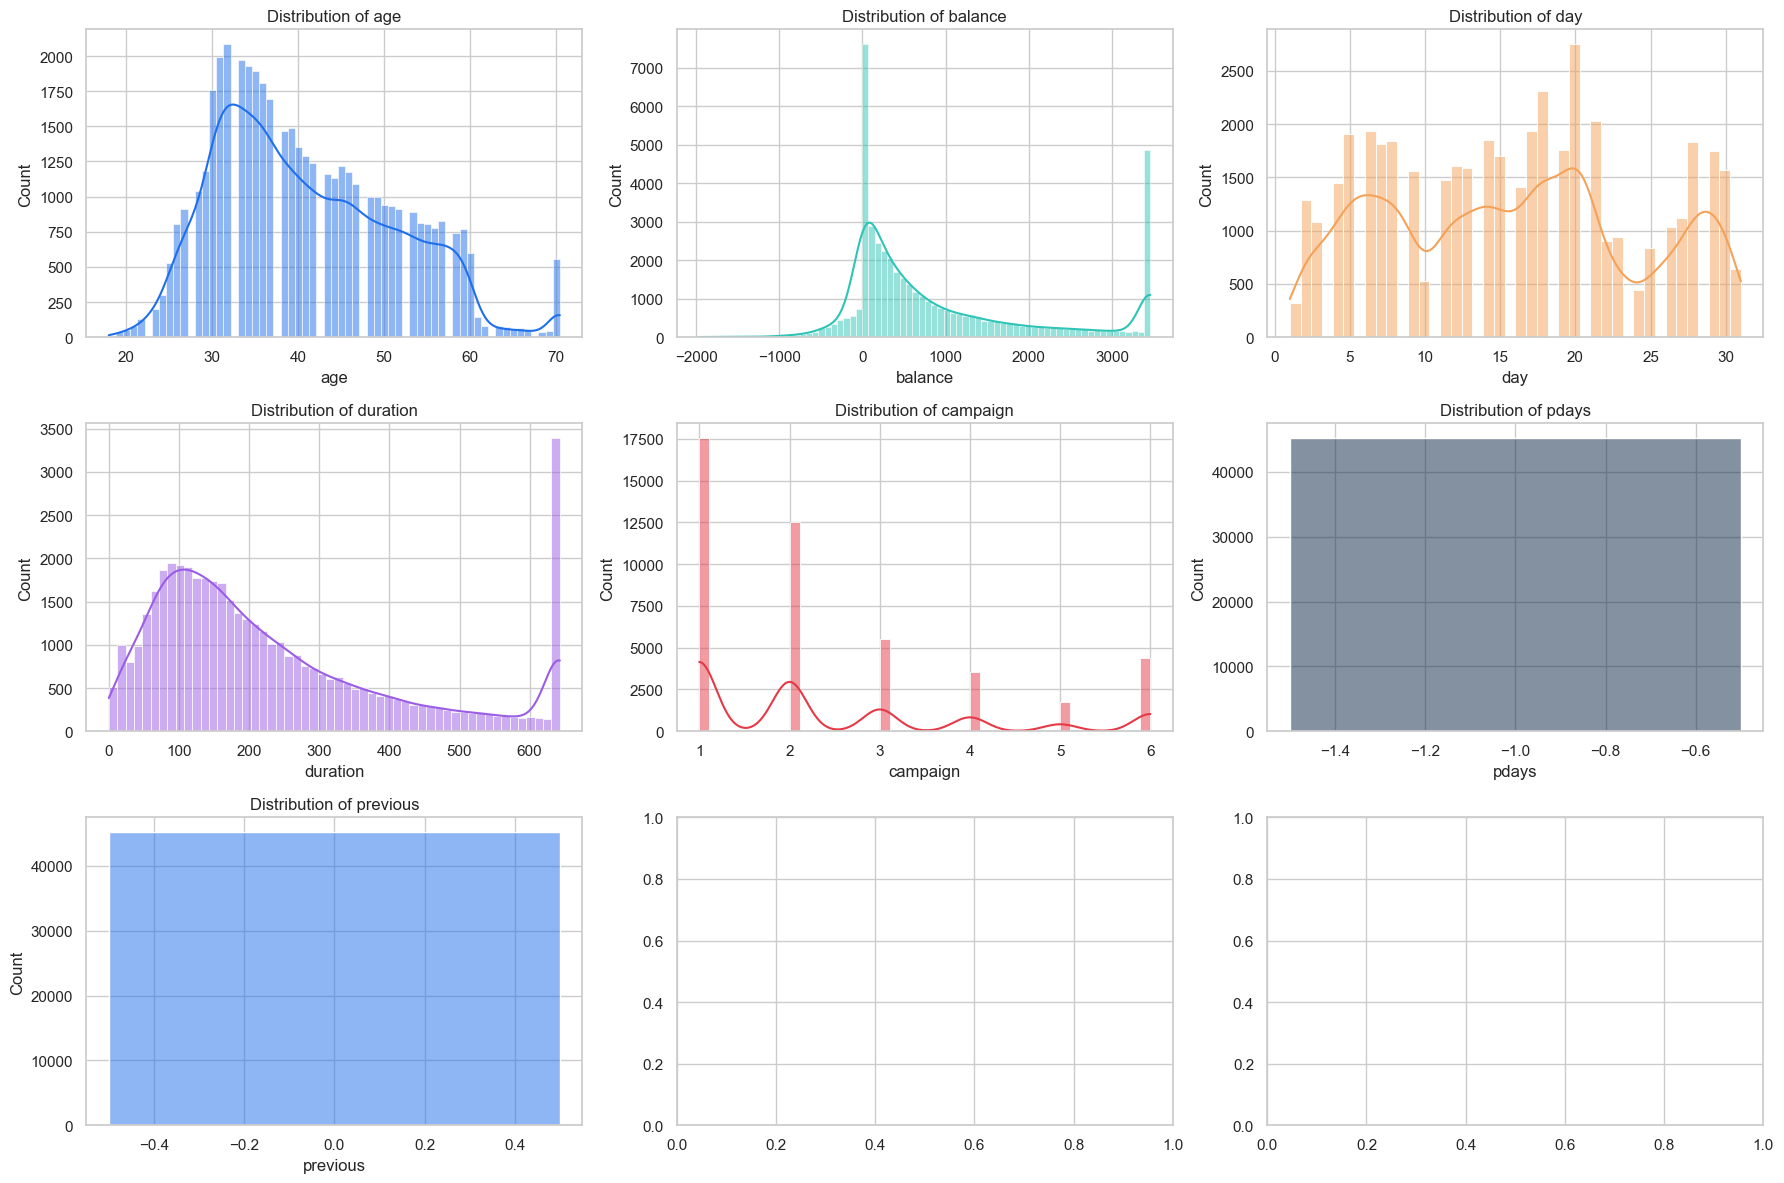

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\4155124298.py:24: UserWarning: 
The palette list has fewer values (6) than needed (11) and will cycle, which may produce an uninterpretable plot.
  ax = sns.countplot(data=df_clean, y=col, hue=col, order=df_clean[col].value_counts().index, palette=COLOR_PALETTE, legend=False)


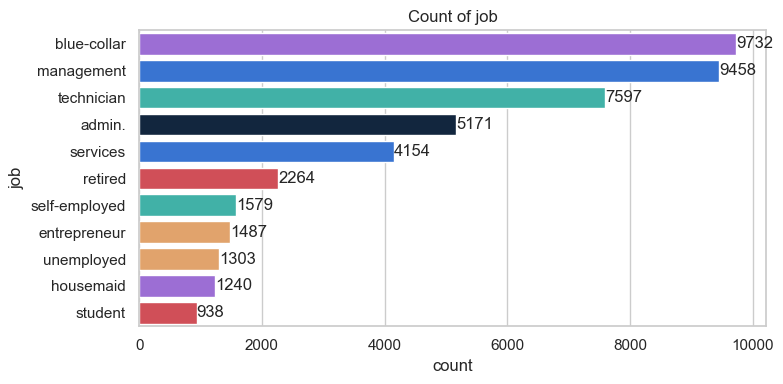

**job**: most frequent category is **blue-collar**.

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\4155124298.py:24: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax = sns.countplot(data=df_clean, y=col, hue=col, order=df_clean[col].value_counts().index, palette=COLOR_PALETTE, legend=False)


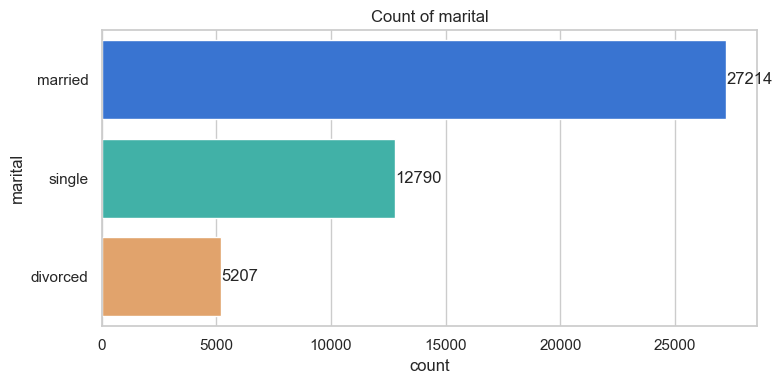

**marital**: most frequent category is **married**.

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\4155124298.py:24: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax = sns.countplot(data=df_clean, y=col, hue=col, order=df_clean[col].value_counts().index, palette=COLOR_PALETTE, legend=False)


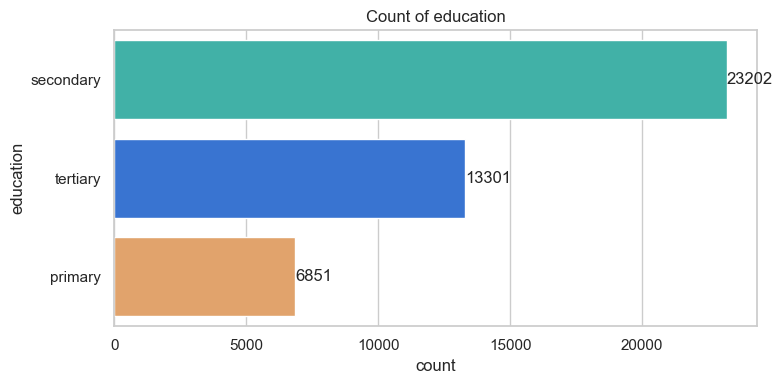

**education**: most frequent category is **secondary**.

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\4155124298.py:24: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.countplot(data=df_clean, y=col, hue=col, order=df_clean[col].value_counts().index, palette=COLOR_PALETTE, legend=False)


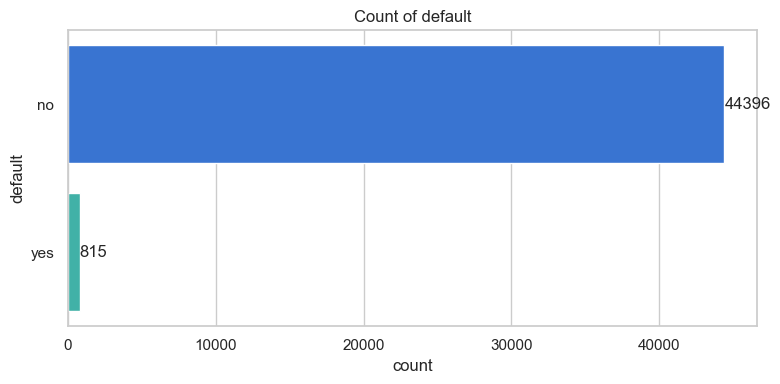

**default**: most frequent category is **no**.

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\4155124298.py:24: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.countplot(data=df_clean, y=col, hue=col, order=df_clean[col].value_counts().index, palette=COLOR_PALETTE, legend=False)


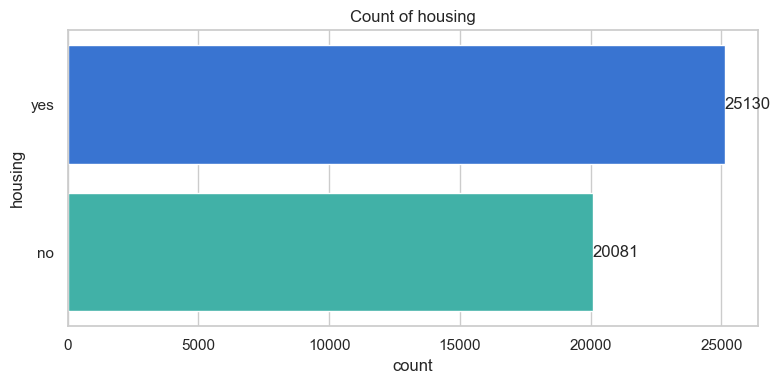

**housing**: most frequent category is **yes**.

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\4155124298.py:24: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.countplot(data=df_clean, y=col, hue=col, order=df_clean[col].value_counts().index, palette=COLOR_PALETTE, legend=False)


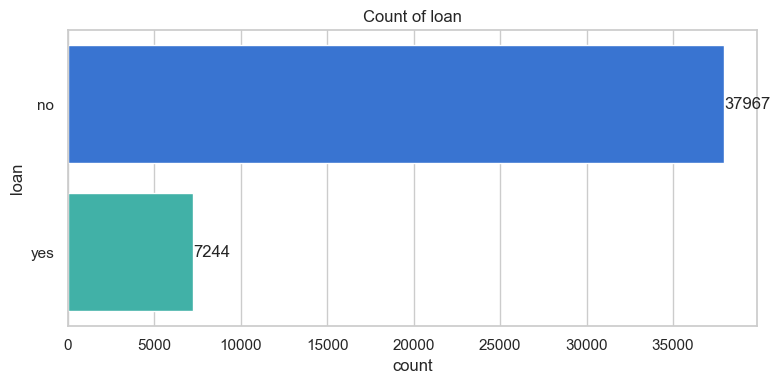

**loan**: most frequent category is **no**.

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\4155124298.py:24: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.countplot(data=df_clean, y=col, hue=col, order=df_clean[col].value_counts().index, palette=COLOR_PALETTE, legend=False)


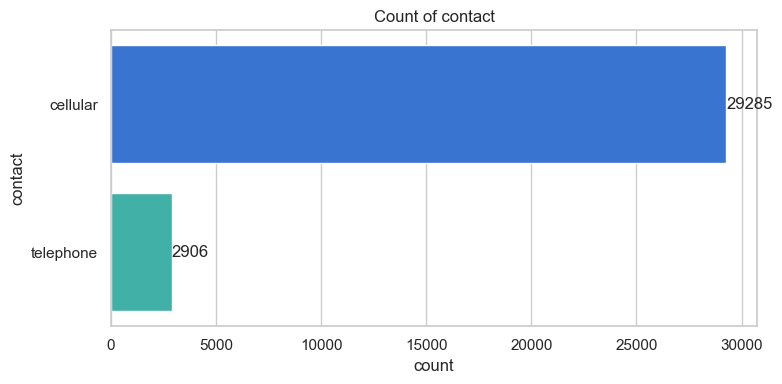

**contact**: most frequent category is **cellular**.

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\4155124298.py:24: UserWarning: 
The palette list has fewer values (6) than needed (12) and will cycle, which may produce an uninterpretable plot.
  ax = sns.countplot(data=df_clean, y=col, hue=col, order=df_clean[col].value_counts().index, palette=COLOR_PALETTE, legend=False)


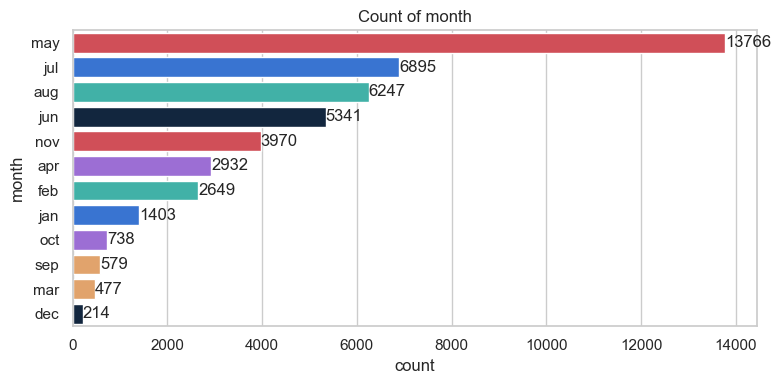

**month**: most frequent category is **may**.

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\4155124298.py:24: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax = sns.countplot(data=df_clean, y=col, hue=col, order=df_clean[col].value_counts().index, palette=COLOR_PALETTE, legend=False)


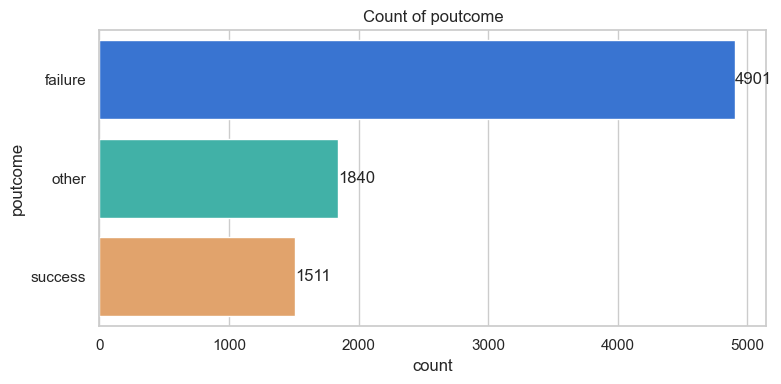

**poutcome**: most frequent category is **failure**.

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\4155124298.py:24: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.countplot(data=df_clean, y=col, hue=col, order=df_clean[col].value_counts().index, palette=COLOR_PALETTE, legend=False)


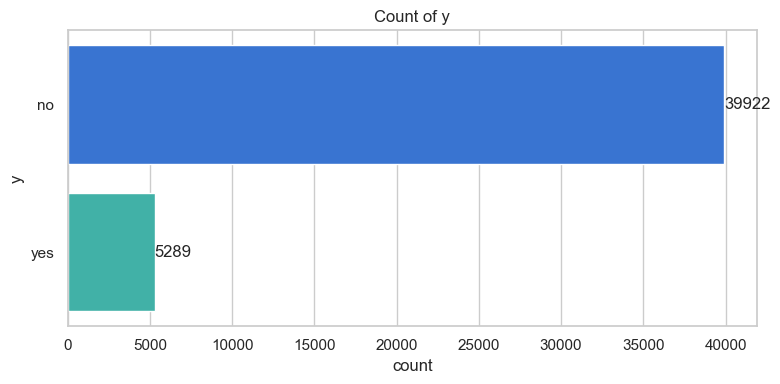

**y**: most frequent category is **no**.

In [7]:
# Numeric distributions
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.ravel()
for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color=COLOR_PALETTE[i % len(COLOR_PALETTE)])
    axes[i].set_title(f"Distribution of {col}")
    skew = df_clean[col].skew()
    if skew > 0.5:
        skew_label = "right-skewed"
    elif skew < -0.5:
        skew_label = "left-skewed"
    else:
        skew_label = "approximately symmetric"
    display(Markdown(f"**{col}**: skew={skew:.2f} ({skew_label})."))
plt.tight_layout()
plt.show()

# Categorical distributions
categorical_cols = [
    "job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome", "y"
]
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(data=df_clean, y=col, hue=col, order=df_clean[col].value_counts().index, palette=COLOR_PALETTE, legend=False)
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(f"Count of {col}")
    plt.tight_layout()
    plt.show()

    top_value = df_clean[col].value_counts().index[0]
    display(Markdown(f"**{col}**: most frequent category is **{top_value}**."))


## 5. Bivariate Analysis
We compare key features against subscription outcomes to identify business drivers.

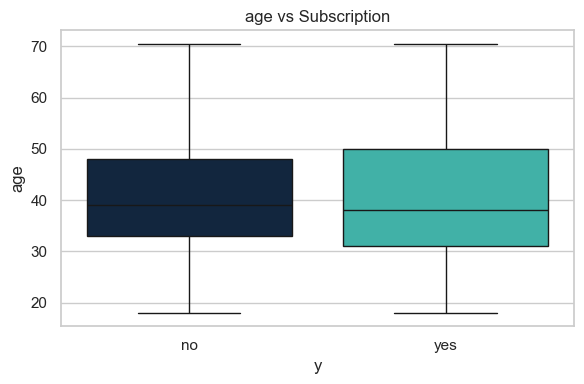

**age**: mean is 41.41 for subscribers vs 40.80 for non-subscribers.

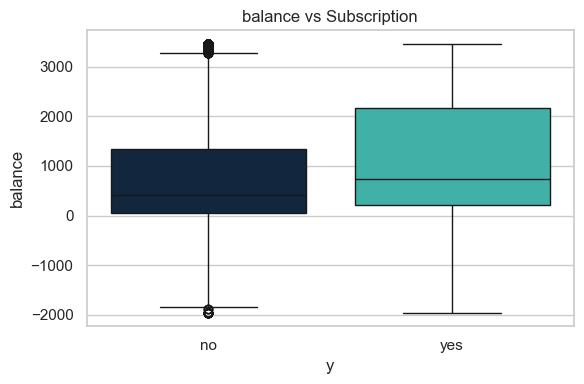

**balance**: mean is 1234.13 for subscribers vs 893.91 for non-subscribers.

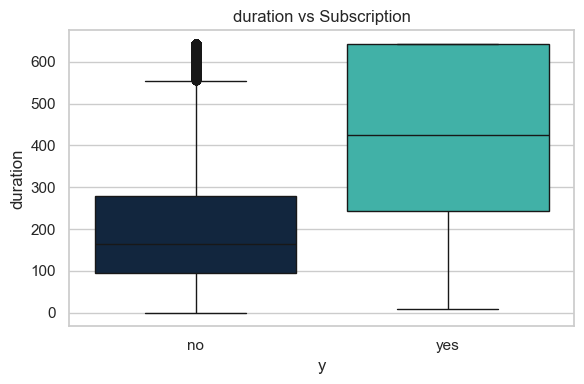

**duration**: mean is 424.64 for subscribers vs 209.81 for non-subscribers.

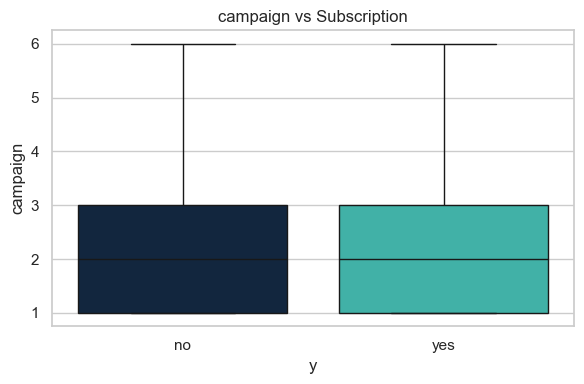

**campaign**: mean is 2.02 for subscribers vs 2.44 for non-subscribers.

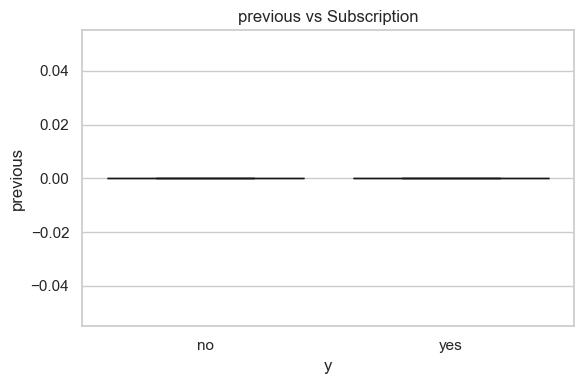

**previous**: mean is 0.00 for subscribers vs 0.00 for non-subscribers.

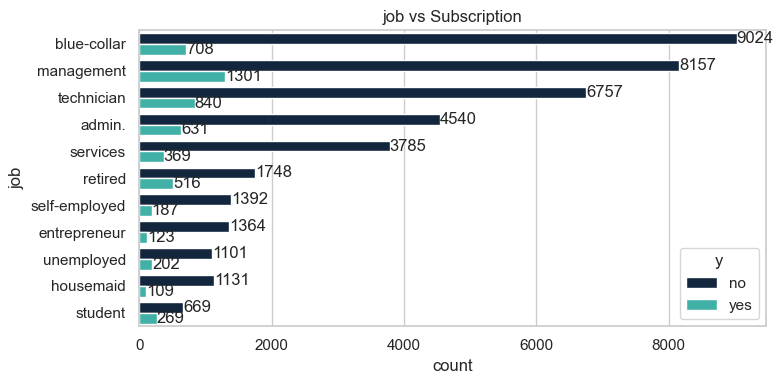

**job**: subscription rate ranges from 7.3% to 28.7% across categories (highest: student).

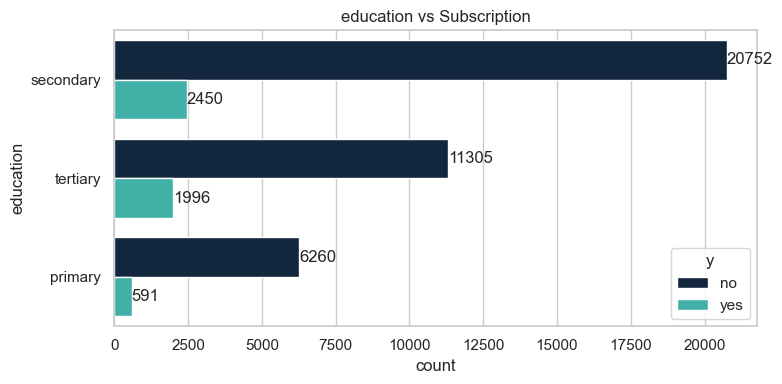

**education**: subscription rate ranges from 8.6% to 15.0% across categories (highest: tertiary).

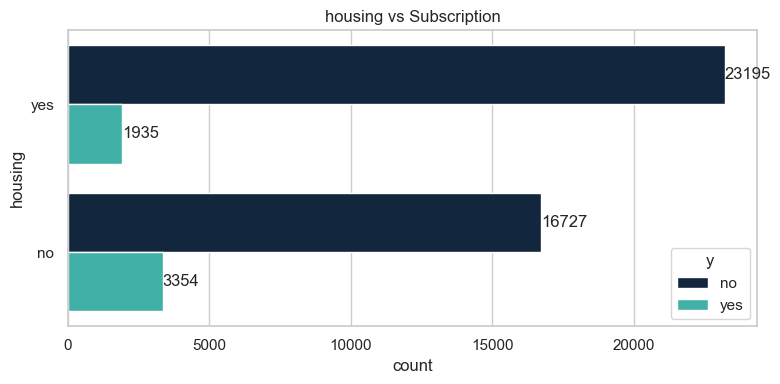

**housing**: subscription rate ranges from 7.7% to 16.7% across categories (highest: no).

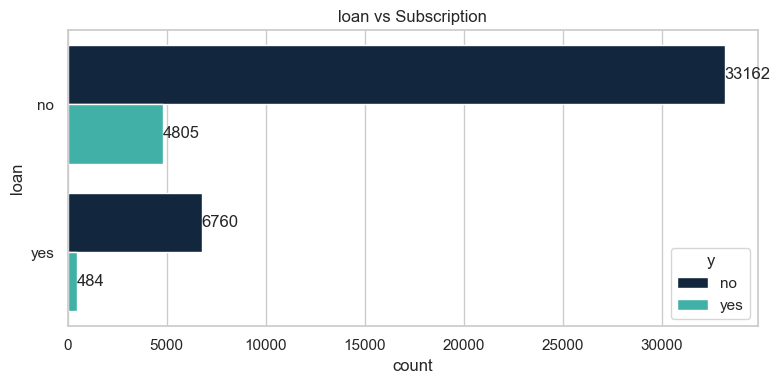

**loan**: subscription rate ranges from 6.7% to 12.7% across categories (highest: no).

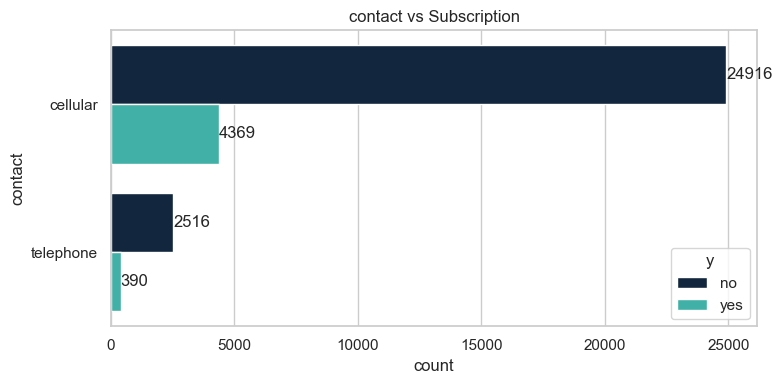

**contact**: subscription rate ranges from 13.4% to 14.9% across categories (highest: cellular).

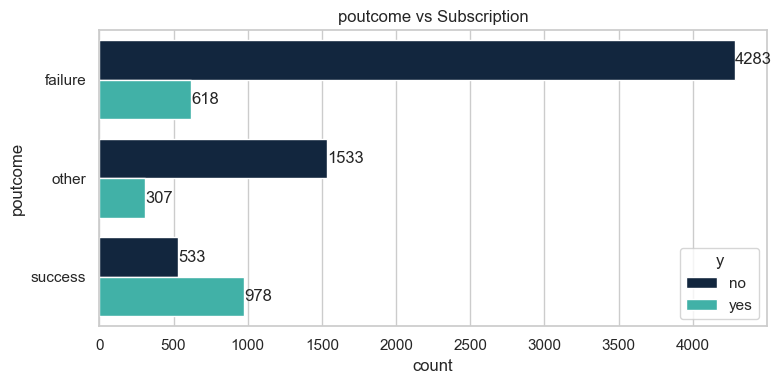

**poutcome**: subscription rate ranges from 12.6% to 64.7% across categories (highest: success).

In [8]:
# Numeric features vs target
for col in ["age", "balance", "duration", "campaign", "previous"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_clean, x="y", y=col, hue="y", palette=OUTCOME_PALETTE, legend=False)
    plt.title(f"{col} vs Subscription")
    plt.tight_layout()
    plt.show()

    means = df_clean.groupby("y")[col].mean()
    display(Markdown(
        f"**{col}**: mean is {means['yes']:.2f} for subscribers vs {means['no']:.2f} for non-subscribers."
    ))

# Categorical features vs target
for col in ["job", "education", "housing", "loan", "contact", "poutcome"]:
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(data=df_clean, y=col, hue="y", order=df_clean[col].value_counts().index, palette=OUTCOME_PALETTE)
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(f"{col} vs Subscription")
    plt.tight_layout()
    plt.show()

    rates = df_clean.groupby(col)["y"].apply(lambda s: (s == "yes").mean()) * 100
    display(Markdown(
        f"**{col}**: subscription rate ranges from {rates.min():.1f}% to {rates.max():.1f}% "
        f"across categories (highest: {rates.idxmax()})."
    ))


## 6. Multivariate Analysis
We explore correlations and feature interactions to understand joint effects.

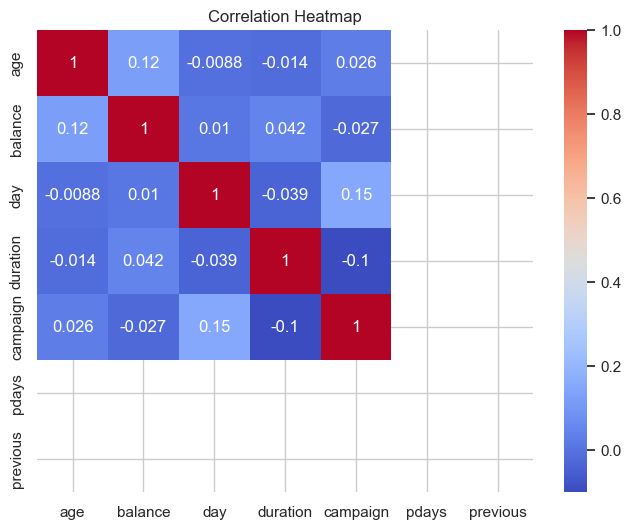

E:\Programming\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
E:\Programming\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


**Strongest numeric predictor of subscription:** duration (correlation = 0.39).

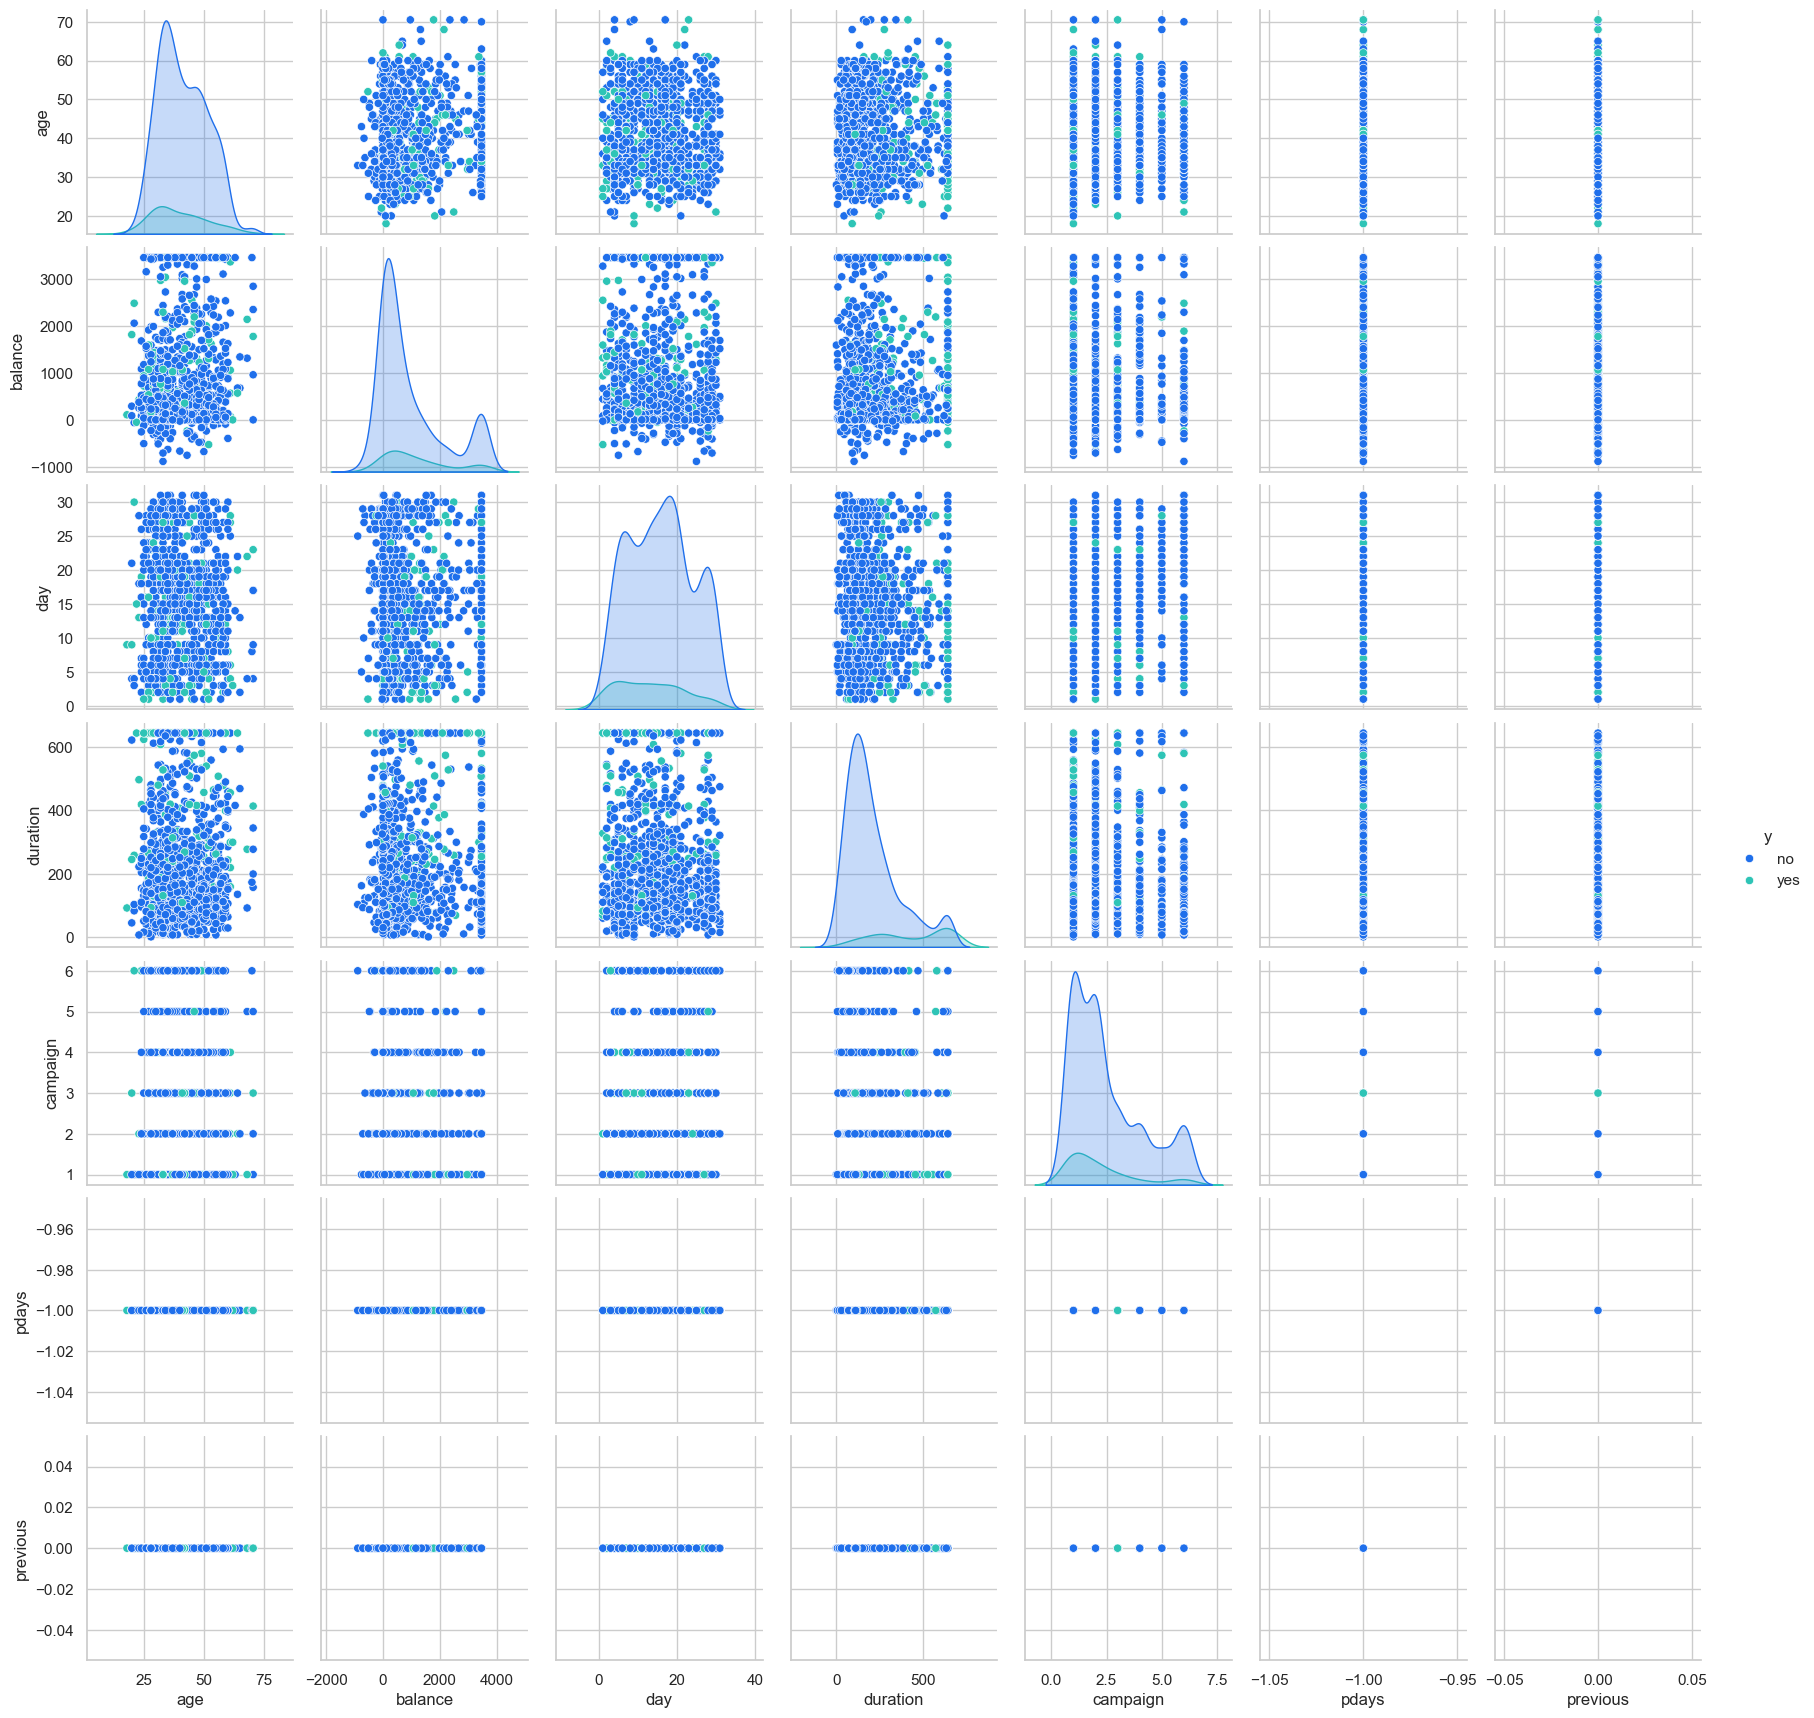

Pairwise relationships between numeric features, colored by subscription outcome.

C:\Users\elhos\AppData\Local\Temp\ipykernel_27996\3243166336.py:29: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax = sns.barplot(data=segment, x="job", y="subscription_rate", hue="education", palette=COLOR_PALETTE)


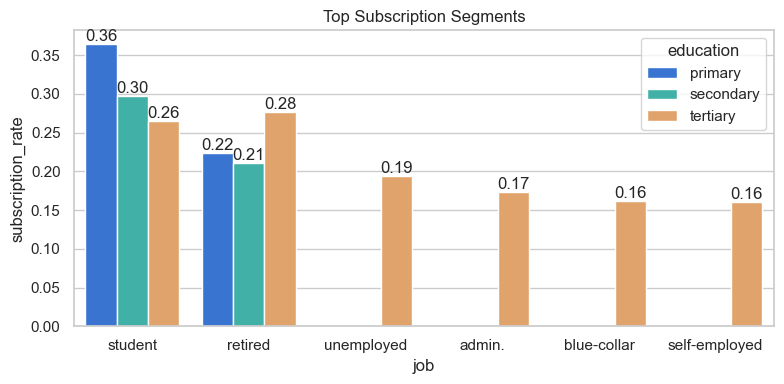

**Top segment:** student / primary with a 36.4% subscription rate.

In [9]:
# Correlation heatmap
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

y_num = (df_clean["y"] == "yes").astype(int)
corr_with_y = df_clean[numeric_cols].corrwith(y_num).sort_values(ascending=False)
display(Markdown(
    f"**Strongest numeric predictor of subscription:** {corr_with_y.index[0]} "
    f"(correlation = {corr_with_y.iloc[0]:.2f})."
))

# Pairplot on a sample to keep runtime reasonable
sample_df = df_clean.sample(1000, random_state=42)
sns.pairplot(sample_df[numeric_cols + ["y"]], hue="y")
plt.show()
display(Markdown("Pairwise relationships between numeric features, colored by subscription outcome."))

# Top job/education segments by subscription rate
segment = (
    df_clean.groupby(["job", "education"])["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
)
segment = segment.sort_values("subscription_rate", ascending=False).head(10)
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=segment, x="job", y="subscription_rate", hue="education", palette=COLOR_PALETTE)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.title("Top Subscription Segments")
plt.tight_layout()
plt.show()

top_seg = segment.iloc[0]
display(Markdown(
    f"**Top segment:** {top_seg['job']} / {top_seg['education']} "
    f"with a {top_seg['subscription_rate'] * 100:.1f}% subscription rate."
))


## 7. Key Insights
Summarize the strongest patterns and business recommendations based on the analysis.

- Subscription rates vary significantly across job (7%-29%) and education (9%-15%) groups.
- Call duration is the strongest numeric predictor of subscription (correlation ~0.39).
- Prior campaign outcome is highly predictive: customers with a previous "success" subscribe ~65% of the time vs ~13% for others.
- More contacts during the current campaign are weakly associated with lower subscription (correlation ~-0.08).
- Targeting high-engagement segments (e.g., students, tertiary education, prior successes) is recommended.


## Important Note on Duration
`duration` is measured after the call is completed. It is strongly correlated with the target and can cause data leakage for pre-campaign prediction. We will build models with and without `duration` in the ML notebook and deploy the no-duration model for realistic pre-contact use cases.

## 8. Feature Engineering
We create business-driven features to capture engagement, financial stability, and risk.

In [10]:
# Feature engineering
df_fe = df_clean.copy()
df_fe['Customer_Engagement_Index'] = df_fe['campaign'] + df_fe['previous']
df_fe['Financial_Stability_Index'] = df_fe['balance'] / df_fe['age']
df_fe['Marketing_Effectiveness'] = df_fe['duration'] / df_fe['campaign']
df_fe['Previous_Campaign_Success'] = (df_fe['poutcome'] == 'success').astype(int)
df_fe['Loan_Risk_Index'] = (df_fe['housing'] == 'yes').astype(int) + (df_fe['loan'] == 'yes').astype(int)

df_fe[['Customer_Engagement_Index', 'Financial_Stability_Index', 'Marketing_Effectiveness', 'Previous_Campaign_Success', 'Loan_Risk_Index']].describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Engagement_Index,45211.0,2.392228,1.600111,1.000000,1.000000,2.000000,3.000000,6.000000
Financial_Stability_Index,45211.0,23.502042,30.609322,-75.461538,1.828427,11.461538,35.895946,182.210526
Marketing_Effectiveness,45211.0,146.715331,144.506866,0.000000,45.000000,100.000000,199.000000,643.000000
Previous_Campaign_Success,45211.0,0.033421,0.179735,0.000000,0.000000,0.000000,0.000000,1.000000
Loan_Risk_Index,45211.0,0.716065,0.629689,0.000000,0.000000,1.000000,1.000000,2.000000


## 9. Feature Selection
We apply mutual information and XGBoost feature importance for ranking.

,feature,mi_score
0,duration,0.072017
1,Marketing_Effectiveness,0.070766
2,poutcome_success,0.031033
3,poutcome_failure,0.025827
4,Previous_Campaign_Success,0.024815
5,Financial_Stability_Index,0.018519
6,balance,0.017780
7,housing_yes,0.016790
8,Loan_Risk_Index,0.015367
9,age,0.012583


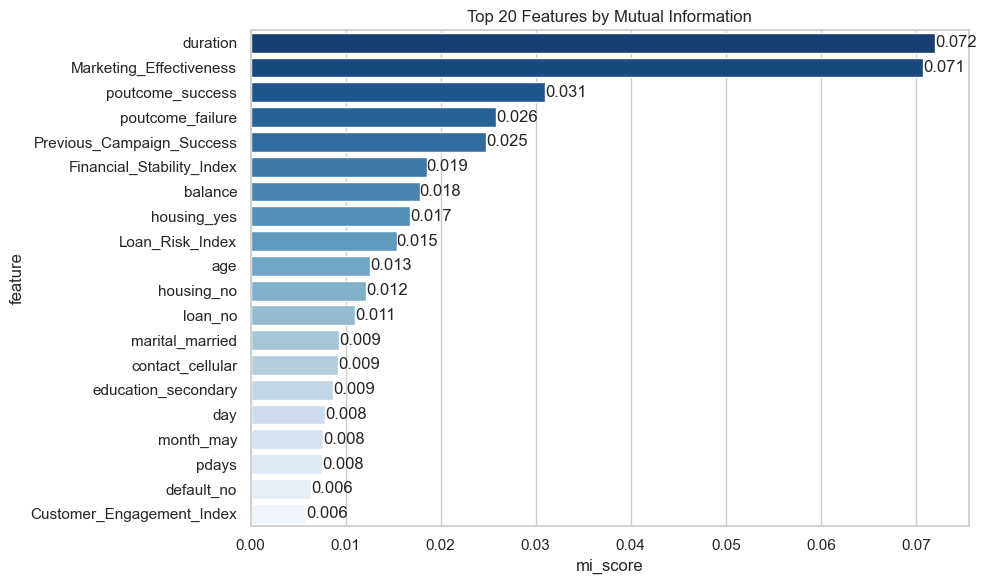

**Top feature by mutual information:** duration.

In [11]:
# Mutual information feature selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
import xgboost as xgb

X = df_fe.drop(columns=["y"])
y = (df_fe["y"] == "yes").astype(int)

cat_cols = X.select_dtypes(include=["object", "category"]).columns
num_cols = X.select_dtypes(exclude=["object", "category"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

X_processed = preprocess.fit_transform(X)

# Feature names after one-hot encoding
num_features = list(num_cols)
cat_features = list(
    preprocess.named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(cat_cols)
)
feature_names = num_features + cat_features

# Mutual information (filter method)
mi_scores = mutual_info_classif(X_processed, y, random_state=42)
mi_df = pd.DataFrame({"feature": feature_names, "mi_score": mi_scores})
mi_df = mi_df.sort_values("mi_score", ascending=False).reset_index(drop=True)
display(mi_df.head(20))

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=mi_df.head(20), x="mi_score", y="feature", hue="feature", palette="Blues_r", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
plt.title("Top 20 Features by Mutual Information")
plt.tight_layout()
plt.show()
display(Markdown(f"**Top feature by mutual information:** {mi_df.iloc[0]['feature']}."))


,feature,xgb_importance
0,Previous_Campaign_Success,0.171644
1,poutcome_success,0.115385
2,duration,0.060089
3,Loan_Risk_Index,0.048733
4,month_mar,0.043888
5,Marketing_Effectiveness,0.038434
6,campaign,0.035132
7,month_oct,0.030693
8,housing_no,0.030392
9,month_sep,0.028422


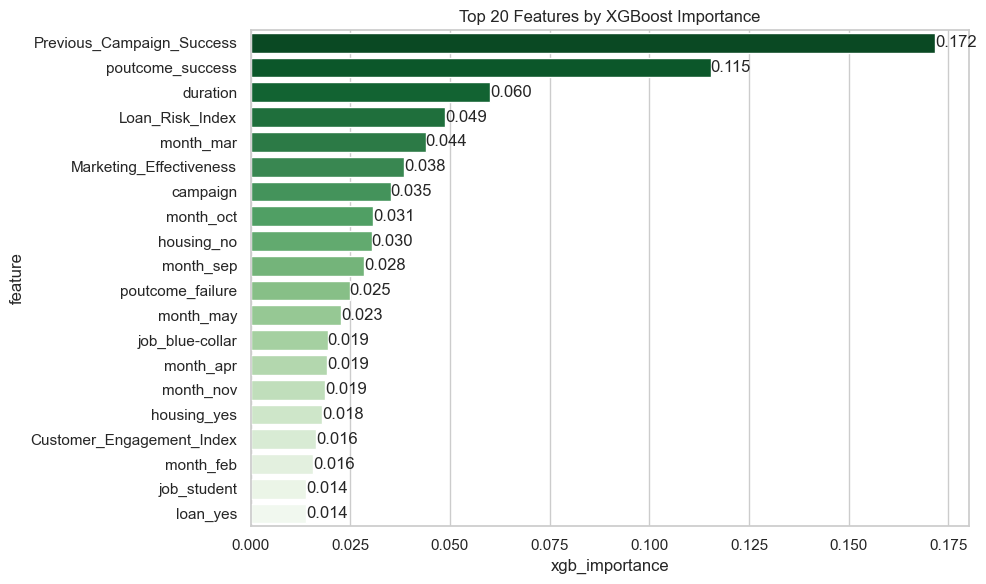

**Top feature by XGBoost importance:** Previous_Campaign_Success.

,feature,rfe_rank
0,pdays,1
1,job_housemaid,1
2,Previous_Campaign_Success,1
3,Loan_Risk_Index,1
4,job_student,1
5,job_retired,1
6,month_may,1
7,month_oct,1
8,month_jan,1
9,month_jul,1


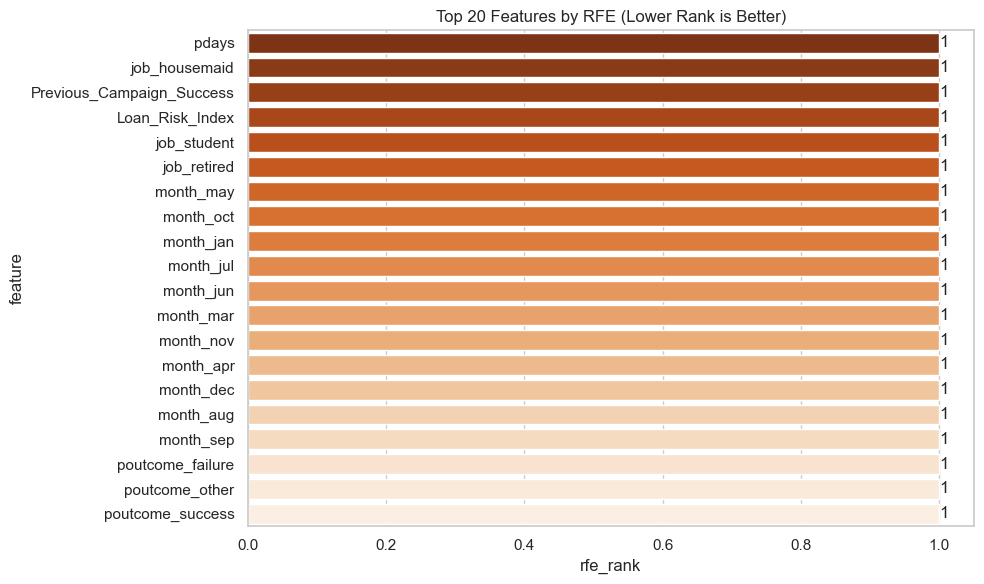

,feature,mi_rank,xgb_rank,rfe_rank,selected_final
0,duration,1.0,3.0,27,True
1,Marketing_Effectiveness,2.0,6.0,30,True
2,poutcome_success,3.0,2.0,1,True
3,poutcome_failure,4.0,11.0,1,True
4,Previous_Campaign_Success,5.0,1.0,1,True
5,Financial_Stability_Index,6.0,33.0,28,False
6,balance,7.0,35.0,32,False
7,housing_yes,8.0,16.0,8,True
8,Loan_Risk_Index,9.0,4.0,1,True
9,age,10.0,22.0,31,False


Features selected by at least two of the three methods (mutual information, RFE, XGBoost importance) form the final candidate set.

In [12]:
# Embedded method: XGBoost feature importance
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb_model.fit(X_processed, y)

xgb_df = pd.DataFrame({
    "feature": feature_names,
    "xgb_importance": xgb_model.feature_importances_
}).sort_values("xgb_importance", ascending=False).reset_index(drop=True)
display(xgb_df.head(20))

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=xgb_df.head(20), x="xgb_importance", y="feature", hue="feature", palette="Greens_r", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
plt.title("Top 20 Features by XGBoost Importance")
plt.tight_layout()
plt.show()
display(Markdown(f"**Top feature by XGBoost importance:** {xgb_df.iloc[0]['feature']}."))

# Wrapper method: Recursive Feature Elimination
rfe_estimator = LogisticRegression(max_iter=2000, solver="liblinear")
rfe = RFE(estimator=rfe_estimator, n_features_to_select=20)
rfe.fit(X_processed, y)

rfe_df = pd.DataFrame({
    "feature": feature_names,
    "rfe_rank": rfe.ranking_
}).sort_values("rfe_rank", ascending=True).reset_index(drop=True)
display(rfe_df.head(20))

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=rfe_df.head(20), x="rfe_rank", y="feature", hue="feature", palette="Oranges_r", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.title("Top 20 Features by RFE (Lower Rank is Better)")
plt.tight_layout()
plt.show()

# Compare filter, wrapper, and embedded rankings
mi_rank = mi_df.set_index("feature")["mi_score"].rank(ascending=False)
xgb_rank = xgb_df.set_index("feature")["xgb_importance"].rank(ascending=False)
rfe_rank = rfe_df.set_index("feature")["rfe_rank"]
comparison = pd.DataFrame({
    "feature": feature_names,
    "mi_rank": [mi_rank[f] for f in feature_names],
    "xgb_rank": [xgb_rank[f] for f in feature_names],
    "rfe_rank": [rfe_rank[f] for f in feature_names],
})
comparison["selected_final"] = (
    (comparison["mi_rank"] <= 20).astype(int)
    + (comparison["xgb_rank"] <= 20).astype(int)
    + (comparison["rfe_rank"] <= 20).astype(int)
    >= 2
)
comparison = comparison.sort_values("mi_rank").reset_index(drop=True)
display(comparison.head(30))

display(Markdown(
    "Features selected by at least two of the three methods "
    "(mutual information, RFE, XGBoost importance) form the final candidate set."
))


## Export Cleaned Dataset
We export the cleaned and feature-engineered dataset for modeling.

In [13]:
output_path = project_root / "cleaned_bank_dataset.csv"
df_fe.to_csv(output_path, index=False)
print("Saved:", output_path)

Saved: C:\Users\elhos\OneDrive\Desktop\ML Final project\cleaned_bank_dataset.csv
